# Import

In [56]:
import torch
from torch import nn
from torch.utils.data import dataset,dataloader
from torchvision import datasets, transforms
import requests
import zipfile
from pathlib import Path
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

torch. __version__

'2.13.0'

In [3]:
device = 'mps' if torch.mps.is_available() else 'cpu'
device

'mps'

# Get Data

In [4]:
data_path = Path("./data")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f'{image_path} exists.')

else:
    print(f'{image_path} does not exist.')
    image_path.mkdir(parents=True, exist_ok=True)

with  open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
    f.write(request.content)

with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", 'r') as zip_ref:
    print('Unpacking pizza_steak_sushi.zip')
    zip_ref.extractall(image_path)

data/pizza_steak_sushi exists.
Unpacking pizza_steak_sushi.zip


In [7]:
 train_dir = image_path / "train"
 test_dir = image_path / "test"

# Visualizing

Random image path: data/pizza_steak_sushi/train/sushi/3004029.jpg
Image Class: sushi
Height: 512, Width: 512


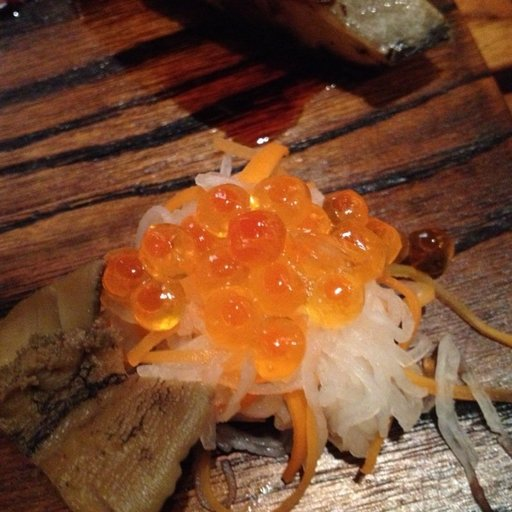

In [55]:
# Get all image paths
image_path_list = list(image_path.glob('*/*/*.jpg')) # Search all the .jpg images at the third directory level: 1 test/2 pizza/3 search here.jpg

# Pick a random image path
random_image_path = random.choice(image_path_list)

# Get the image class
image_class = random_image_path.parent.stem # parent refers to the complete path where the image is stored and stem if the last folder that contains that image

# Open the image
img = Image.open(random_image_path)

# Print metadata
print(f'Random image path: {random_image_path}')
print(f'Image Class: {image_class}')
print(f'Height: {img.height}, Width: {img.width}')

img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

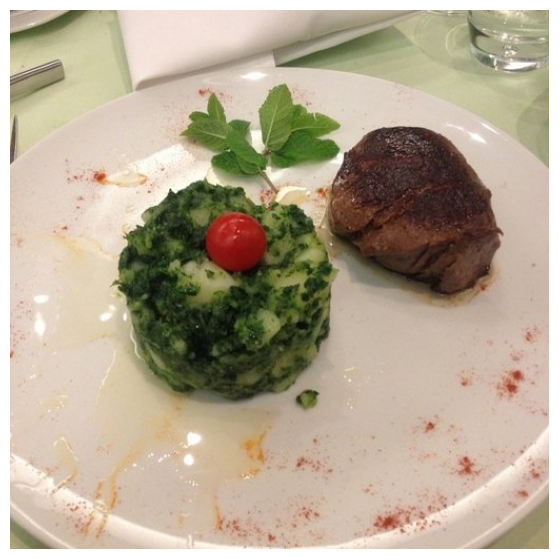

In [54]:
# Get all image paths
image_path_list = list(image_path.glob('*/*/*.jpg'))

img_as_array = np.asarray(img)

plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.axis(False)

In [ ]:
data_transform = transforms.Compose([transforms.Resize(size=(64, 64)),
                                     transforms.RandomHorizontalFlip(p=0.5),
                                     transforms.ToTensor()])